# SmartStock AI: Exploratory Demand Analysis

This notebook explores historical sales, pricing, promotions, weather, events, and inventory levels. It is descriptive only: no production model is trained.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (12, 5)


In [3]:
data_candidates = [
    Path("../data/sample/sample_sales_data.csv"),
    Path("data/sample/sample_sales_data.csv"),
]
data_path = next(path for path in data_candidates if path.exists())
sales = pd.read_csv(data_path, parse_dates=["date"])
sales = sales.sort_values("date").reset_index(drop=True)
sales["event"] = sales["event"].fillna("No event")

sales.info()
display(sales.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1365 entries, 0 to 1364
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1365 non-null   datetime64[ns]
 1   product_id    1365 non-null   object        
 2   warehouse_id  1365 non-null   object        
 3   units_sold    1365 non-null   int64         
 4   stock_level   1365 non-null   int64         
 5   price         1365 non-null   float64       
 6   promotion     1365 non-null   bool          
 7   temperature   1365 non-null   float64       
 8   event         1365 non-null   object        
dtypes: bool(1), datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 86.8+ KB


,date,product_id,warehouse_id,units_sold,stock_level,price,promotion,temperature,event
0,2022-01-01,SKU-0001,WH-01,57,1465,30.76,False,21.9,No event
1,2022-01-01,SKU-0005,WH-03,108,2712,88.94,False,21.9,No event
2,2022-01-01,SKU-0005,WH-02,99,1612,50.12,False,21.9,No event
3,2022-01-01,SKU-0005,WH-01,105,2087,86.35,False,21.9,No event
4,2022-01-01,SKU-0004,WH-03,107,1326,64.62,False,21.9,No event


## Data overview and derived time dimensions

In [4]:
overview = pd.Series({
    "rows": len(sales),
    "date_start": sales["date"].min().date(),
    "date_end": sales["date"].max().date(),
    "total_units_sold": sales["units_sold"].sum(),
    "products": sales["product_id"].nunique(),
    "warehouses": sales["warehouse_id"].nunique(),
})
display(overview.to_frame("value"))

sales["day"] = sales["date"].dt.date
sales["week"] = sales["date"].dt.to_period("W").apply(lambda period: period.start_time)
sales["month"] = sales["date"].dt.to_period("M").dt.to_timestamp()
sales["day_of_week"] = sales["date"].dt.day_name()
sales["month_name"] = sales["date"].dt.month_name()


,value
rows,1365
date_start,2022-01-01
date_end,2022-04-01
total_units_sold,116373
products,5
warehouses,3


## 1-4. Demand over time: total, daily, weekly, and monthly

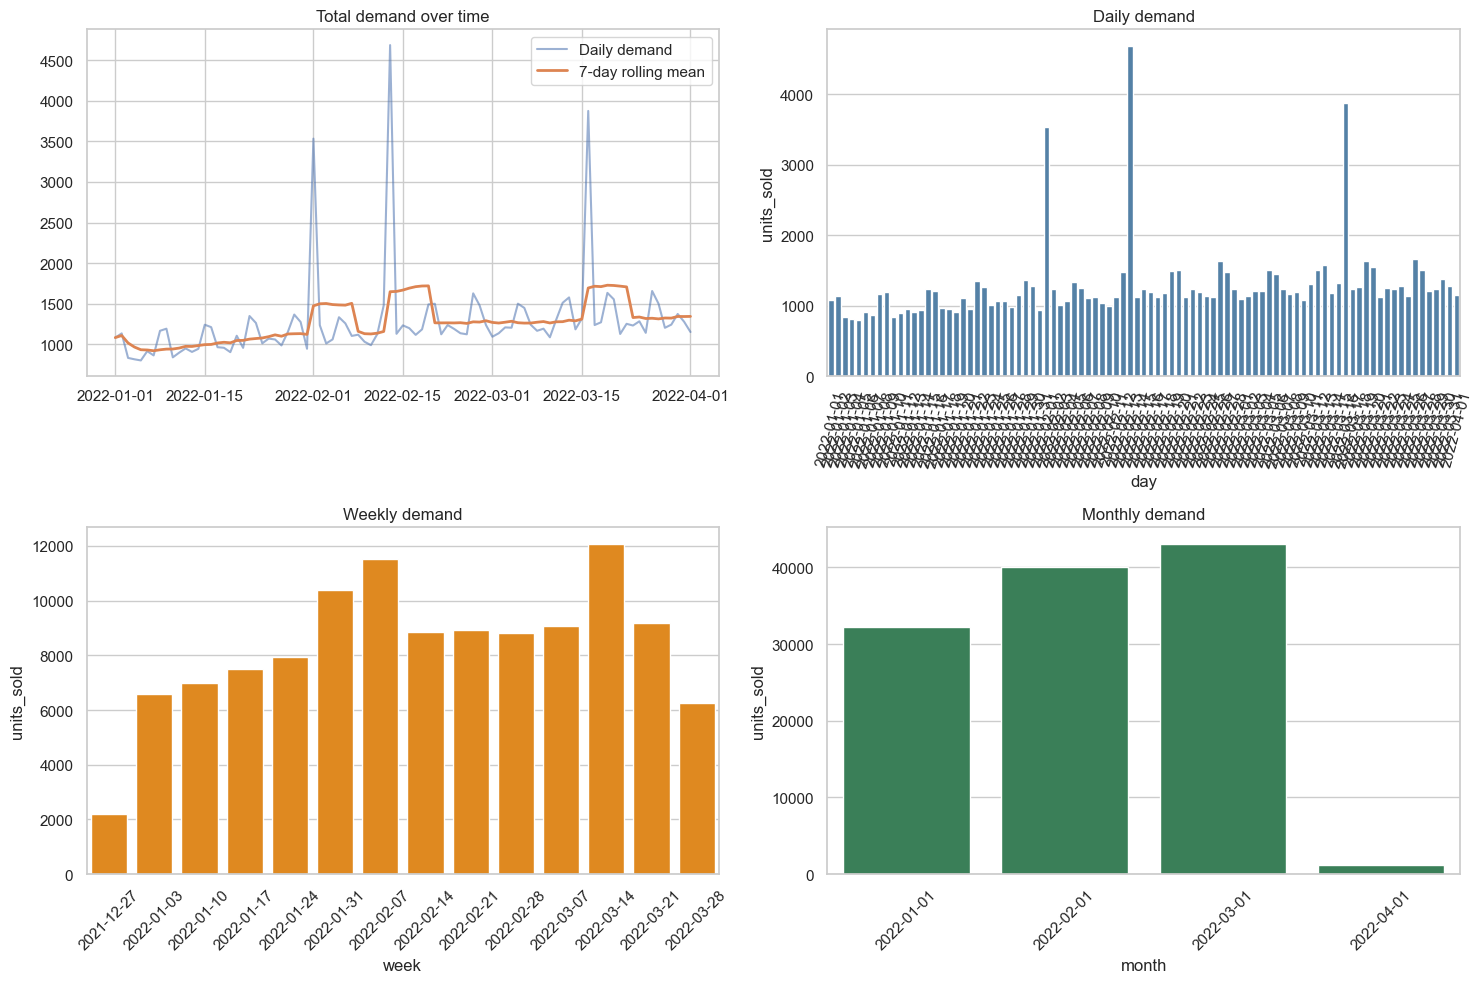

In [5]:
daily_demand = sales.groupby("day", as_index=False)["units_sold"].sum()
daily_demand["day"] = pd.to_datetime(daily_demand["day"])
daily_demand["rolling_7d"] = daily_demand["units_sold"].rolling(7, min_periods=1).mean()
weekly_demand = sales.groupby("week", as_index=False)["units_sold"].sum()
monthly_demand = sales.groupby("month", as_index=False)["units_sold"].sum()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes[0, 0].plot(daily_demand["day"], daily_demand["units_sold"], alpha=.55, label="Daily demand")
axes[0, 0].plot(daily_demand["day"], daily_demand["rolling_7d"], linewidth=2, label="7-day rolling mean")
axes[0, 0].set_title("Total demand over time")
axes[0, 0].legend()
sns.barplot(data=daily_demand, x="day", y="units_sold", ax=axes[0, 1], color="steelblue")
axes[0, 1].set_title("Daily demand")
axes[0, 1].tick_params(axis="x", rotation=75)
sns.barplot(data=weekly_demand, x="week", y="units_sold", ax=axes[1, 0], color="darkorange")
axes[1, 0].set_title("Weekly demand")
axes[1, 0].tick_params(axis="x", rotation=45)
sns.barplot(data=monthly_demand, x="month", y="units_sold", ax=axes[1, 1], color="seagreen")
axes[1, 1].set_title("Monthly demand")
axes[1, 1].tick_params(axis="x", rotation=45)
plt.tight_layout()


## 5-6. Demand by product and warehouse

,index,product_id,sum,mean,count
4,4,SKU-0005,32193,117.923077,273
3,3,SKU-0004,27217,99.695971,273
1,1,SKU-0002,24645,90.274725,273
0,0,SKU-0001,21768,79.736264,273
2,2,SKU-0003,10550,38.644689,273


,index,warehouse_id,sum,mean,count
2,2,WH-03,44114,96.953846,455
1,1,WH-02,38163,83.874725,455
0,0,WH-01,34096,74.936264,455


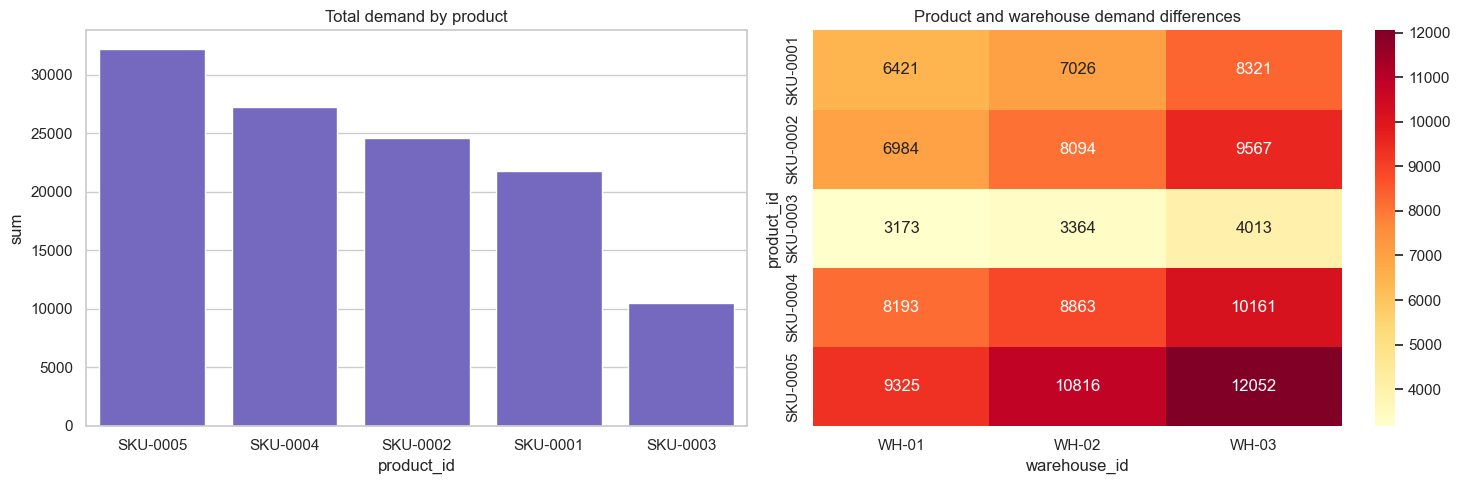

In [6]:
product_demand = sales.groupby("product_id", as_index=False)["units_sold"].agg(["sum", "mean", "count"]).reset_index()
warehouse_demand = sales.groupby("warehouse_id", as_index=False)["units_sold"].agg(["sum", "mean", "count"]).reset_index()
display(product_demand.sort_values("sum", ascending=False))
display(warehouse_demand.sort_values("sum", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=product_demand.sort_values("sum", ascending=False), x="product_id", y="sum", ax=axes[0], color="slateblue")
axes[0].set_title("Total demand by product")
sns.barplot(data=warehouse_demand.sort_values("sum", ascending=False), x="warehouse_id", y="sum", ax=axes[1], color="teal")
axes[1].set_title("Total demand by warehouse")
plt.tight_layout()

product_warehouse = sales.pivot_table(index="product_id", columns="warehouse_id", values="units_sold", aggfunc="sum")
sns.heatmap(product_warehouse, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Product and warehouse demand differences")
plt.tight_layout()


## 7-10. Promotion, price, temperature, and events versus demand

,sum,mean,count
promotion,,,
False,107723,83.183784,1295
True,8650,123.571429,70


,sum,mean,count
event,,,
No event,104278,78.998485,1320
SpecialEvent,12095,268.777778,45


Promotion-demand correlation: 0.17
Price-demand correlation: -0.019
Temperature-demand correlation: 0.158


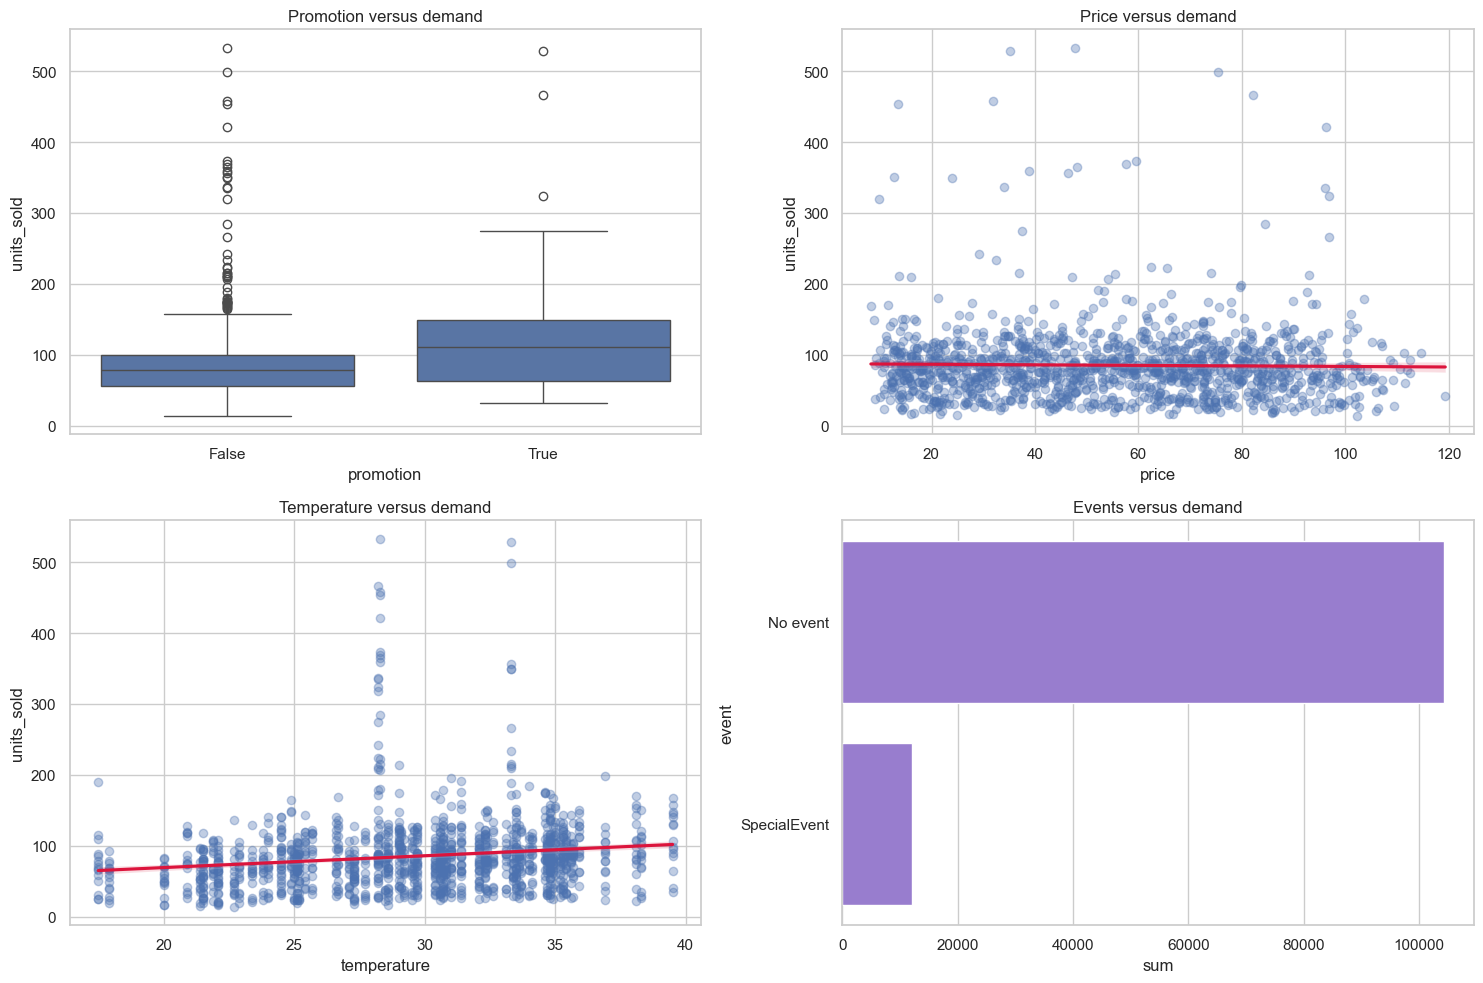

In [8]:
promotion_summary = sales.groupby("promotion")["units_sold"].agg(["sum", "mean", "count"])
event_summary = sales.groupby("event")["units_sold"].agg(["sum", "mean", "count"]).sort_values("sum", ascending=False)
display(promotion_summary)
display(event_summary)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.boxplot(data=sales, x="promotion", y="units_sold", ax=axes[0, 0])
axes[0, 0].set_title("Promotion versus demand")
sns.regplot(data=sales, x="price", y="units_sold", scatter_kws={"alpha": .35}, line_kws={"color": "crimson"}, ax=axes[0, 1])
axes[0, 1].set_title("Price versus demand")
sns.regplot(data=sales, x="temperature", y="units_sold", scatter_kws={"alpha": .35}, line_kws={"color": "crimson"}, ax=axes[1, 0])
axes[1, 0].set_title("Temperature versus demand")
event_plot = event_summary.reset_index().sort_values("sum", ascending=False)
sns.barplot(data=event_plot, x="sum", y="event", ax=axes[1, 1], color="mediumpurple")
axes[1, 1].set_title("Events versus demand")
plt.tight_layout()

print("Promotion-demand correlation:", sales["promotion"].astype(int).corr(sales["units_sold"]).round(3))
print("Price-demand correlation:", sales["price"].corr(sales["units_sold"]).round(3))
print("Temperature-demand correlation:", sales["temperature"].corr(sales["units_sold"]).round(3))


## 11. Stock levels over time

Stock-level versus demand correlation: 0.882


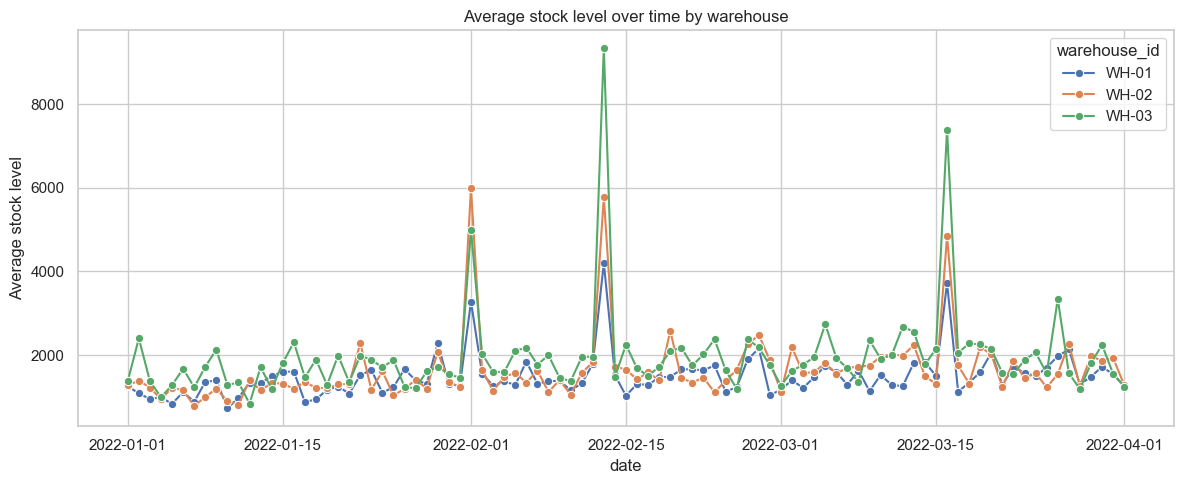

In [9]:
daily_stock = sales.groupby(["date", "warehouse_id"], as_index=False)["stock_level"].mean()
sns.lineplot(data=daily_stock, x="date", y="stock_level", hue="warehouse_id", marker="o")
plt.title("Average stock level over time by warehouse")
plt.ylabel("Average stock level")
plt.tight_layout()

stock_demand = sales[["stock_level", "units_sold"]].corr().iloc[0, 1]
print(f"Stock-level versus demand correlation: {stock_demand:.3f}")


## 12. Seasonality, outliers, and demand spikes

,sum,mean
day_of_week,,
Monday,13952,71.548718
Tuesday,16942,86.882051
Wednesday,17185,88.128205
Thursday,14268,73.169231
Friday,14493,74.323077
Saturday,18447,94.600000
Sunday,21086,108.133333


,sum,mean
month_name,,
April,1152,76.800000
February,39990,95.214286
January,32178,69.200000
March,43053,92.587097


Row-level demand outliers: 49


,date,product_id,warehouse_id,units_sold,price
19,2022-01-02,SKU-0004,WH-03,190,53.38
465,2022-02-01,SKU-0005,WH-02,467,82.24
466,2022-02-01,SKU-0005,WH-01,211,13.67
467,2022-02-01,SKU-0004,WH-03,336,34.10
468,2022-02-01,SKU-0004,WH-02,178,57.69
469,2022-02-01,SKU-0004,WH-01,319,9.81
472,2022-02-01,SKU-0005,WH-03,335,96.09
473,2022-02-01,SKU-0002,WH-03,242,29.15
474,2022-02-01,SKU-0002,WH-02,209,16.02
476,2022-02-01,SKU-0001,WH-03,324,96.96


Daily demand spikes (z-score >= 2): 3


,day,units_sold,rolling_7d,z_score
43,2022-02-13,4686,1648.428571,6.148214
74,2022-03-16,3875,1694.285714,4.684773
31,2022-02-01,3534,1474.571429,4.069442


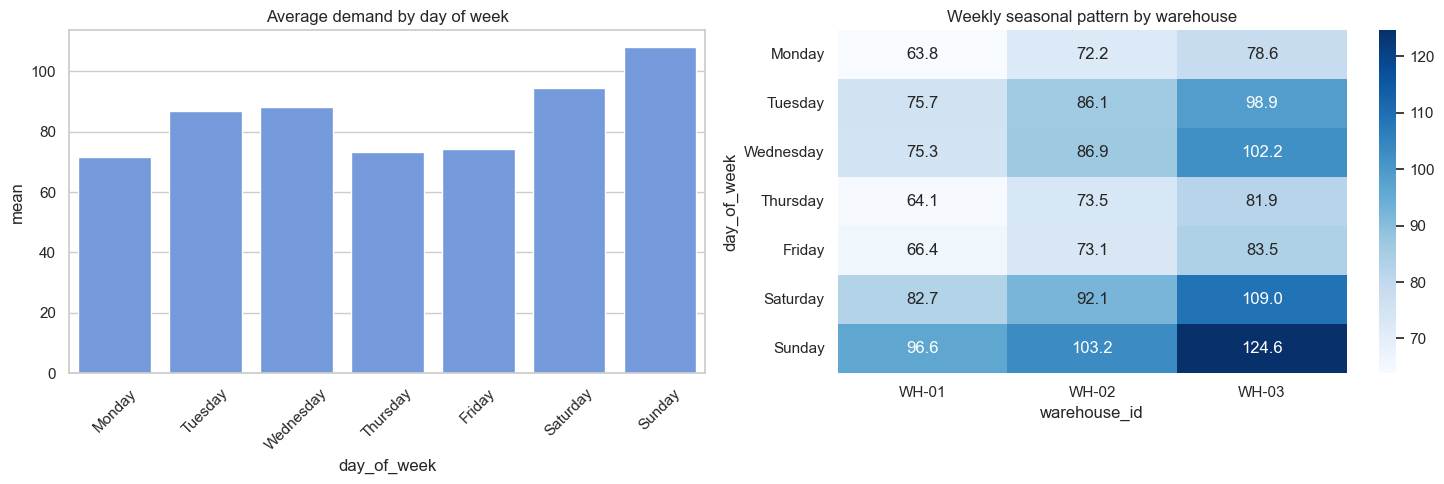

In [10]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_summary = sales.groupby("day_of_week")["units_sold"].agg(["sum", "mean"]).reindex(weekday_order)
month_summary = sales.groupby("month_name")["units_sold"].agg(["sum", "mean"])
display(weekday_summary)
display(month_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(x=weekday_summary.index, y=weekday_summary["mean"], ax=axes[0], color="cornflowerblue")
axes[0].set_title("Average demand by day of week")
axes[0].tick_params(axis="x", rotation=45)
sns.heatmap(sales.pivot_table(index="day_of_week", columns="warehouse_id", values="units_sold", aggfunc="mean").reindex(weekday_order), annot=True, fmt=".1f", cmap="Blues", ax=axes[1])
axes[1].set_title("Weekly seasonal pattern by warehouse")
plt.tight_layout()

q1, q3 = sales["units_sold"].quantile([.25, .75])
iqr = q3 - q1
outliers = sales.loc[(sales["units_sold"] < q1 - 1.5 * iqr) | (sales["units_sold"] > q3 + 1.5 * iqr)].copy()
daily_demand["z_score"] = (daily_demand["units_sold"] - daily_demand["units_sold"].mean()) / daily_demand["units_sold"].std()
spikes = daily_demand.loc[daily_demand["z_score"] >= 2].sort_values("units_sold", ascending=False)
print(f"Row-level demand outliers: {len(outliers)}")
display(outliers[["date", "product_id", "warehouse_id", "units_sold", "price"]].head(10))
print(f"Daily demand spikes (z-score >= 2): {len(spikes)}")
display(spikes)


## Observations

- Demand rises across the observed period, with the strongest monthly total in March; the final partial month should be interpreted cautiously.
- SKU-0005 and SKU-0004 contribute the most units, while SKU-0003 contributes substantially less. WH-03 leads total demand and WH-01 trails it.
- Promotional rows have higher average demand than non-promotional rows, but promotion frequency is much lower, so this is an association rather than a causal estimate.
- The price, temperature, and stock plots/correlations provide directional relationships to investigate; they should not be interpreted as causal effects without controls.
- The outlier and spike tables identify unusually large individual transactions and days for follow-up. Weekly patterns and the warehouse heatmap reveal operational differences and possible seasonal effects.
- No production model is trained in this notebook; the findings are intended to guide later feature engineering and forecasting work.